In [1]:
import scipy as sp
from scipy.optimize import curve_fit
from scipy.fft import fft, ifft
from scipy.special import jv, hankel1, hankel2, yv, yvp, jvp
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array, einsum, angle, exp, cos, sin
from utils import hl1_prime, hl2_prime, h_z_cpa_numerator, h_z_cpa, e_z_cpa, h_z_recursive_cpa, e_z_recursive_cpa

## This notebook is related to the paper: [Broadband subwavelength focusing of light using a passive sink](https://opg.optica.org/oe/fulltext.cfm?uri=oe-21-15-17435)

### In lieu of cylindrical waves, we consider the effect of a passive sink/coherent perfect absorber on an incident plane wave. As a sanity check, we first verify the Jacobi-Anger relationship for scalar plane waves. This relation reads: $e^{iz\cos(\theta)}=\sum_{m=-\infty}^{\infty} (i)^m J_m(z)e^{im\theta}$. By using the fact that $J_{-m}(z)=(-1)^m J_m(z)$, we may rewrite the Jacobi-Anger identity as follows: $e^{iz\cos(\theta)}=J_0(z)+\sum_{m=1}^{\infty} \Big[(i)^mJ_m(z)e^{im\theta}+(i)^{-m}J_{-m}(z)e^{-im\theta} \Big]= J_0(z)+\sum_{m=1}^\infty (i)^m J_m(z)\Big[e^{im\theta}+(i)^{-2m}(-1)^m e^{-im\theta} \Big]=J_0(z)+2\sum_{m=1}^\infty (i)^m J_m(z)\cos(m\theta)$

In [2]:
# n_max is the cutoff 
def jacobi_anger(n_max, z, theta):
    result = jv(0, z) + 0j
    for n in range(1, n_max+1):
        result += 2*((1j)**n)*jv(n, z)*cos(n*theta)
    return result

### In the below, we check the convergence of with respect to the cutoff, $n_{max}$ of the Bessel functions

In [3]:
N = 10000
z_s = linspace(0.1, 20, N)
theta = 0
n_max_v = [4, 16, 64]
plane_wave = exp(1j*z_s*cos(theta))
jacobi_expansion_v = []
for n_max in n_max_v:
    jacobi_expansion = jacobi_anger(n_max, z_s, theta)
    jacobi_expansion_v.append(jacobi_expansion)

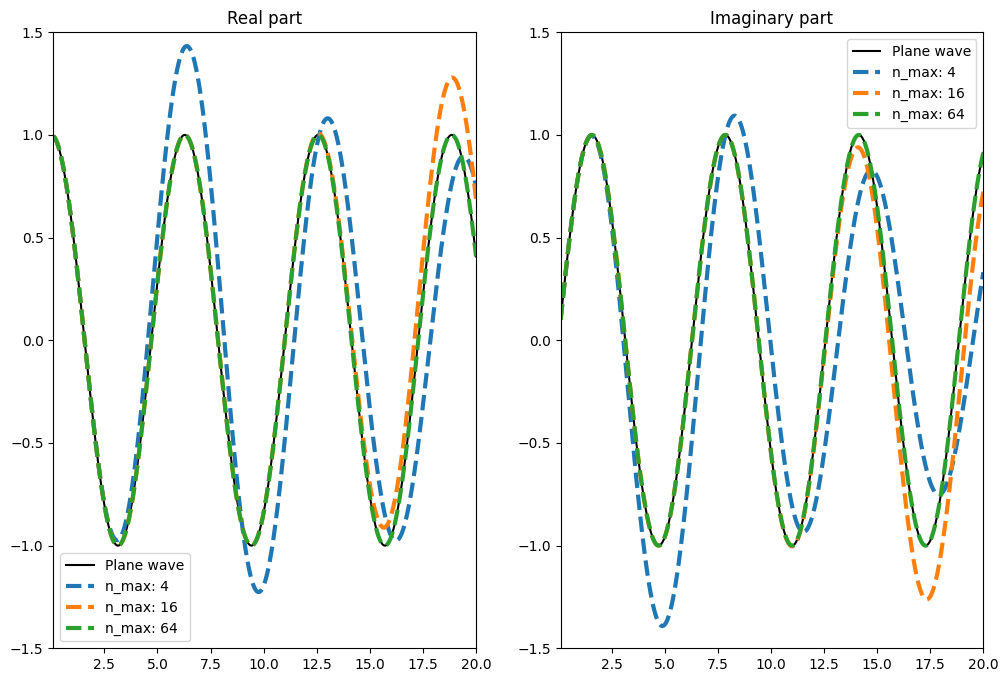

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
ax1.plot(z_s, plane_wave.real, linestyle="solid", color="black", label="Plane wave")
for (n_max, jacobi_expansion) in zip(n_max_v, jacobi_expansion_v):
    ax1.plot(z_s, jacobi_expansion.real, linestyle="dashed", linewidth=3, label=f"n_max: {n_max}")
ax1.legend();
ax1.set_ylim(-1.5, 1.5);
ax1.set_xlim(z_s.min(), z_s.max());

ax2.plot(z_s, plane_wave.imag, linestyle="solid", color="black", label="Plane wave")
for (n_max, jacobi_expansion) in zip(n_max_v, jacobi_expansion_v):
    ax2.plot(z_s, jacobi_expansion.imag, linestyle="dashed", linewidth=3, label=f"n_max: {n_max}")
ax2.legend();
ax2.set_ylim(-1.5, 1.5);
ax2.set_xlim(z_s.min(), z_s.max());
ax1.set_title("Real part")
ax2.set_title("Imaginary part");

### Now we find the enhancement of the local field upon plane wave excitation. We write the magnetic field (polarized in the $e_z$ direction) outside of the scatterer as  as $2He^{ikr\cos(\theta)}=\sum_{m=-\infty}^{\infty} (i)^m \Bigg[H^{(1)}_m(kr)+H^{(2)}_m(kr)+(s_m-1)H^{(1)}_m(kr)\Bigg]e^{im\theta}$. In this expression, $s_m$ is the scattering coefficient we obtain through, for instance, *h_z_cpa* in *utils.py*. Therefore, we need to calculate all $s_m$ for $|m|<m_{max}$, where $m_{max}$ is some cutoff

In [31]:
lambda_air = 532 # wavelength in air of the incident light in nm
R = 5.1 # Radius of the cylindrical scatterer
x = (2*pi/lambda_air)*R # kR
m_max = 10

In [32]:
def E_scatterer_s(s, m, lambda_air, r):
    k = (2*pi/lambda_air)
    kr = k*r
    if s==1:
        return (1j*m/r)*(jv(m, kr)), -k*(jvp(m, kr)) # If s=1, to avoid numerical issues, we go directly to the Bessel functions of the first kind 
        #instead of representing them as sums of Hankel functions
    return (1j*m/r)*(hankel2(m, kr) + s*hankel1(m, kr))/2, -k*(hl2_prime(m, kr) + s*hl1_prime(m, kr))/2 

In [36]:
ms = [1, 2]
epsilon_m_1 = -1.0116 # approximate epsilon for s_1=-1 for
epsilon_m_2 = -1.0012159 # approximate epsilon for s_2=-1
normalized_scatterer_intensity_v = []
for (chosen_m, epsilon_m) in zip(ms, [epsilon_m_1, epsilon_m_2]):
    print(f"Chosen_m: {chosen_m}")
    s_m_v = []
    for m in range(-m_max, m_max):
        s_m = h_z_cpa(m, x, epsilon_m+0j)
        s_m_v.append(s_m)
        
    s_m_v_fixed = []
    for (m, s_m) in zip(range(-m_max, m_max), s_m_v):
        if m==-chosen_m or m==chosen_m: # We assume epsilon has been tuned perfectly
            s_m_v_fixed.append(-1+0j)
        else:
            s_m_v_fixed.append(s_m.round(5))

    E_scatterer_rho = 0 + 0j
    E_scatterer_theta = 0 + 0j
    E_vacuum_rho = 0 + 0j
    E_vacuum_theta = 0 + 0j
    N = 10000
    rs = linspace(R, 150, N) # From just outside the cylinder to 150 nanometers
    
    s_m_v_vacuum = np.ones_like(s_m_v) # In vacuum, s=1 exactly
    for (m, s_m, s_m_vacuum) in zip(range(-m_max, m_max), s_m_v_fixed, s_m_v_vacuum):
        E_scatterer_rho_m, E_scatterer_theta_m = E_scatterer_s(s_m, m, lambda_air, rs)
        E_vacuum_rho_m, E_vacuum_theta_m = E_scatterer_s(s_m_vacuum, m, lambda_air, rs)
    
        E_scatterer_rho += (1j)**m*E_scatterer_rho_m
        E_scatterer_theta += (1j)**m*E_scatterer_theta_m
    
        E_vacuum_rho += (1j)**m*E_vacuum_rho_m
        E_vacuum_theta += (1j)**m*E_vacuum_theta_m
    scatterer_intensity = np.abs(E_scatterer_theta)**2+np.abs(E_scatterer_rho)**2
    vacuum_intensity = np.abs(E_vacuum_theta)**2+np.abs(E_vacuum_rho)**2
    normalized_scatterer_intensity = scatterer_intensity/vacuum_intensity
    normalized_scatterer_intensity_v.append(normalized_scatterer_intensity)
print("Maximum enhancement for m=1 (divided by 1e5): ", normalized_scatterer_intensity_v[0].max()/1e5);
print("Maximum enhancement for m=1 (divided by 1e8): ", normalized_scatterer_intensity_v[1].max()/1e8);

Chosen_m: 1
Chosen_m: 2
Maximum enhancement for m=1 (divided by 1e5):  1.2614270455959349
Maximum enhancement for m=1 (divided by 1e8):  5.500970924836192


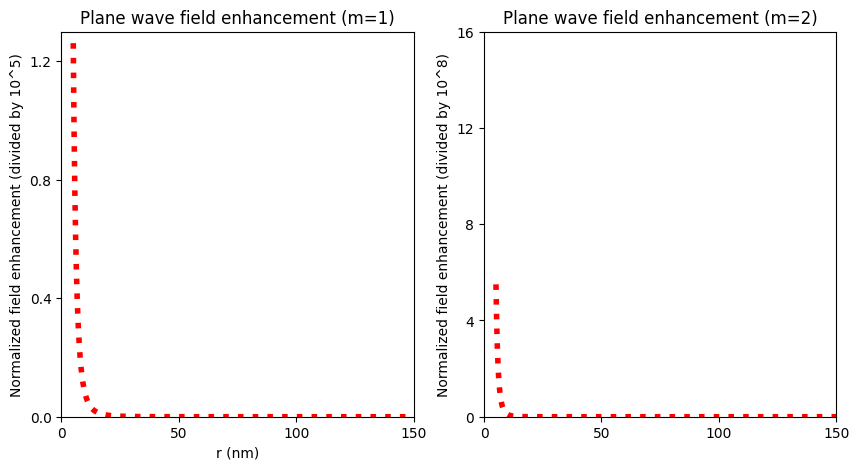

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.plot(rs, normalized_scatterer_intensity_v[0]/1e5, color="red", linewidth=4, linestyle="dotted")
ax1.set_ylim(0, 1.3)
ax2.plot(rs, normalized_scatterer_intensity_v[1]/1e8, color="red", linewidth=4, linestyle="dotted")
ax2.set_ylim(0, 16);
ax1.set_xlim(0, 150)
ax2.set_xlim(0, 150);
ax1.set_title("Plane wave field enhancement (m=1)")
ax2.set_title("Plane wave field enhancement (m=2)")
ax1.set_xlabel("r (nm)")
ax1.set_ylabel("Normalized field enhancement (divided by 10^5)")
ax2.set_ylabel("Normalized field enhancement (divided by 10^8)");
ax1.set_xticks([0, 50, 100, 150])
ax1.set_yticks([0, 0.4, 0.8, 1.2])
ax2.set_xticks([0, 50, 100, 150]);
ax2.set_yticks([0, 4, 8, 12, 16]);